# Dataset 2 — Cityscapes XAI Evaluation

This notebook evaluates the same three XAI techniques used in the BDD100K analysis:

1. **Visual Attention Maps**
2. **Occlusion Sensitivity Analysis**
3. **Multimodal Grad-CAM**



**Imports and Configuration**

In [ ]:
from pathlib import Path
from contextlib import nullcontext
import gc
import json
import re

import cv2
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw
from tqdm.auto import tqdm
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration
from peft import PeftModel
from qwen_vl_utils import process_vision_info

PROJECT_DIR = Path(r"C:\Users\becker\Documents\Thesis")
DATA_DIR = PROJECT_DIR / "dataset" / "CityScapes"
BASE_PATH = DATA_DIR / "cityscapes_base_dataframe.jsonl"
FINE_PATH = DATA_DIR / "cityscapes_finetuned_dataframe.jsonl"

BASE_MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct"
LORA_PATH = PROJECT_DIR / "qwen3vl_bdd100k_lora" / "final_model"

RESULTS_DIR = DATA_DIR / "xai_results_ds2"
MAP_DIR = RESULTS_DIR / "maps"
FIGURE_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MAP_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MIN_PIXELS = 256 * 256
MAX_PIXELS = 384 * 384
OCCLUSION_GRID = (5, 8)
LAST_ATTENTION_LAYERS = 4
EXPECTED_POSITIVES = 20
BOOTSTRAP_SAMPLES = 1000
RANDOM_STATE = 42

METRIC_CHECKPOINT = RESULTS_DIR / "xai_positive_spatial_metrics.csv"

print("XAI configuration ready.")


XAI configuration ready.


**Load Data and Build Hazard Comparison Cases**

In [ ]:
def parse_hazard_decision(text):
    if pd.isna(text) or not str(text).strip():
        return None

    text = " ".join(
        str(text).lower().strip().split()
    )

    decision = re.search(
        r"\bdecision\s*:\s*(yes|no|none)\b",
        text,
    )

    if decision:
        return 1 if decision.group(1) == "yes" else 0

    negative_patterns = [
        r"\bno significant hazards?\b",
        r"\bno hazards?\s+(?:are\s+|is\s+)?detected\b",
        r"\bno hazard detected\b",
        r"\bno immediate hazards?\b",
        r"\bno visible hazards?\b",
        r"\bno potential hazards?\b",
        r"\bno such hazards?\b",
        r"\bhazards?\s*:\s*none\b",
        r"\bhazard type\s*:\s*none\b",
        r"\bnone detected\b",
        r"\bdoes not contain\b.*\bhazard\b",
        r"\bno rule-defined visible potential hazard\b",
        r"\bnot hazardous\b",
    ]

    if any(
        re.search(pattern, text)
        for pattern in negative_patterns
    ):
        return 0

    if re.search(
        r"^\s*potential hazards?\s*:",
        text,
    ):
        return 1

    positive_patterns = [
        r"\bhazard detected\b",
        r"\bhazard is present\b",
        r"\banomaly detected\b",
        r"\bhazard\s*:\s*(?:yes|present|true)\b",
        r"\bhazard type\s*:\s*(?!none\b)",
    ]

    if any(
        re.search(pattern, text)
        for pattern in positive_patterns
    ):
        return 1

    if re.match(r"^\s*no\b", text):
        return 0

    return None


df_base = pd.read_json(
    BASE_PATH,
    orient="records",
    lines=True,
)

df_fine = pd.read_json(
    FINE_PATH,
    orient="records",
    lines=True,
)


required = {
    "evaluation_id",
    "image_id",
    "image_path",
    "label_path",
    "instruction",
    "ground_truth",
    "ground_truth_anomaly",
    "rule_features",
    "predicted_output",
    "task_slug",
}


for name, df in [
    ("Base", df_base),
    ("Fine-tuned", df_fine),
]:
    missing = required - set(df.columns)

    assert not missing, (
        f"{name} dataframe missing: "
        f"{sorted(missing)}"
    )


task = "hazard_and_anomaly_detection"

base_h = (
    df_base[
        df_base["task_slug"] == task
    ]
    .copy()
    .reset_index(drop=True)
)

fine_h = (
    df_fine[
        df_fine["task_slug"] == task
    ]
    .copy()
    .reset_index(drop=True)
)


assert (
    base_h["evaluation_id"].tolist()
    ==
    fine_h["evaluation_id"].tolist()
)

assert (
    base_h[
        "ground_truth_anomaly"
    ]
    .astype(int)
    .tolist()
    ==
    fine_h[
        "ground_truth_anomaly"
    ]
    .astype(int)
    .tolist()
)


hazard_pairs = (
    base_h[
        [
            "evaluation_id",
            "image_id",
            "image_path",
            "label_path",
            "instruction",
            "ground_truth",
            "ground_truth_anomaly",
            "rule_features",
            "predicted_output",
        ]
    ]
    .rename(
        columns={
            "predicted_output":
                "base_output"
        }
    )
    .copy()
)


hazard_pairs["fine_output"] = (
    fine_h[
        "predicted_output"
    ].to_numpy()
)


hazard_pairs["base_prediction"] = (
    hazard_pairs[
        "base_output"
    ].apply(
        parse_hazard_decision
    )
)

hazard_pairs["fine_prediction"] = (
    hazard_pairs[
        "fine_output"
    ].apply(
        parse_hazard_decision
    )
)

# Parser validation
for model_name, prediction_col, output_col in [
    (
        "Base Model",
        "base_prediction",
        "base_output",
    ),
    (
        "Fine-Tuned Model",
        "fine_prediction",
        "fine_output",
    ),
]:

    failures = hazard_pairs[
        hazard_pairs[
            prediction_col
        ].isna()
    ][
        [
            "evaluation_id",
            output_col,
        ]
    ]

    print(
        f"{model_name} unparsed outputs: "
        f"{len(failures)}"
    )

    if len(failures) > 0:
        display(failures)


assert (
    hazard_pairs[
        "base_prediction"
    ].notna().all()
), "Unparsed Base Model hazard outputs remain."

assert (
    hazard_pairs[
        "fine_prediction"
    ].notna().all()
), "Unparsed Fine-Tuned Model hazard outputs remain."


hazard_pairs[
    "ground_truth_anomaly"
] = (
    hazard_pairs[
        "ground_truth_anomaly"
    ]
    .astype(int)
)


hazard_pairs["base_prediction"] = (
    hazard_pairs[
        "base_prediction"
    ]
    .astype(int)
)

hazard_pairs["fine_prediction"] = (
    hazard_pairs[
        "fine_prediction"
    ]
    .astype(int)
)


hazard_pairs["base_correct"] = (
    hazard_pairs[
        "base_prediction"
    ]
    ==
    hazard_pairs[
        "ground_truth_anomaly"
    ]
)

hazard_pairs["fine_correct"] = (
    hazard_pairs[
        "fine_prediction"
    ]
    ==
    hazard_pairs[
        "ground_truth_anomaly"
    ]
)


def comparison_case(row):

    if (
        row["base_correct"]
        and row["fine_correct"]
    ):
        return "Both Correct"

    if (
        not row["base_correct"]
        and row["fine_correct"]
    ):
        return "Fine-Tuned Improvement"

    if (
        row["base_correct"]
        and not row["fine_correct"]
    ):
        return "Fine-Tuned Regression"

    return "Both Incorrect"


hazard_pairs[
    "comparison_case"
] = hazard_pairs.apply(
    comparison_case,
    axis=1,
)


positive_cases = hazard_pairs[
    hazard_pairs[
        "ground_truth_anomaly"
    ] == 1
].copy()


assert (
    len(positive_cases)
    == EXPECTED_POSITIVES
), (
    f"Expected {EXPECTED_POSITIVES} "
    f"positive cases, "
    f"found {len(positive_cases)}."
)


case_distribution = (
    hazard_pairs[
        "comparison_case"
    ]
    .value_counts()
    .rename_axis(
        "Comparison Case"
    )
    .reset_index(
        name="Samples"
    )
)


display(
    case_distribution
)

print(
    "\nPositive proxy cases "
    "for quantitative XAI:",
    len(positive_cases),
)

Base Model unparsed outputs: 0
Fine-Tuned Model unparsed outputs: 0


,Comparison Case,Samples
0,Fine-Tuned Regression,222
1,Fine-Tuned Improvement,20
2,Both Correct,16
3,Both Incorrect,9



Positive proxy cases for quantitative XAI: 20


**Build Proxy-Relevant Polygon Masks**

In [ ]:
def parse_rule_features(value):
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        return json.loads(value)
    return []


def build_proxy_mask(row):
    with open(row["label_path"], "r", encoding="utf-8") as f:
        annotation = json.load(f)

    width = int(annotation["imgWidth"])
    height = int(annotation["imgHeight"])
    objects = annotation["objects"]
    indices = {int(x["object_index"]) for x in parse_rule_features(row["rule_features"])}

    mask_img = Image.new("L", (width, height), 0)
    draw = ImageDraw.Draw(mask_img)

    for idx in indices:
        if idx < 0 or idx >= len(objects):
            raise IndexError(f"Invalid Cityscapes object index {idx}: {row['evaluation_id']}")
        polygon = objects[idx].get("polygon", [])
        if len(polygon) >= 3:
            draw.polygon([tuple(p) for p in polygon], fill=1)

    mask = np.asarray(mask_img, dtype=bool)
    if int(row["ground_truth_anomaly"]) == 1 and not mask.any():
        raise ValueError(f"Empty positive proxy mask: {row['evaluation_id']}")
    return mask


mask_areas = []
for _, row in positive_cases.iterrows():
    mask = build_proxy_mask(row)
    mask_areas.append(mask.mean())

print(f"Validated {len(mask_areas)} positive proxy masks.")
print(f"Mean relevant-region image fraction: {np.mean(mask_areas):.4f}")


Validated 20 positive proxy masks.
Mean relevant-region image fraction: 0.0529


**Load Qwen3-VL and LoRA Adapter**

In [ ]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

assert (LORA_PATH / "adapter_config.json").exists(), f"LoRA adapter not found: {LORA_PATH}"

processor = AutoProcessor.from_pretrained(BASE_MODEL_ID)
dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

base_model = Qwen3VLForConditionalGeneration.from_pretrained(
    BASE_MODEL_ID,
    torch_dtype=dtype,
    device_map="auto",
    attn_implementation="eager",
)

xai_model = PeftModel.from_pretrained(
    base_model,
    str(LORA_PATH),
    is_trainable=False,
)
xai_model.eval()

MODEL_DEVICE = next(xai_model.parameters()).device

visual_merger = next(
    (module for name, module in xai_model.named_modules() if name.endswith("visual.merger")),
    None,
)
assert visual_merger is not None, "Qwen3-VL visual merger could not be located."

print("XAI model ready.")
print("Input device:", MODEL_DEVICE)
print("Base condition: adapter disabled")
print("Fine-tuned condition: adapter enabled")


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

XAI model ready.
Input device: cuda:0
Base condition: adapter disabled
Fine-tuned condition: adapter enabled


**Shared XAI Helpers**

In [ ]:
def model_context(use_adapter):
    return nullcontext() if use_adapter else xai_model.disable_adapter()


def prepare_inputs(row, image):
    messages = [{
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image,
                "min_pixels": MIN_PIXELS,
                "max_pixels": MAX_PIXELS,
            },
            {"type": "text", "text": str(row["instruction"])},
        ],
    }]
    prompt = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[prompt],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    return {
        k: v.to(MODEL_DEVICE) if isinstance(v, torch.Tensor) else v
        for k, v in inputs.items()
    }


def response_ids(text):
    return processor.tokenizer(
        str(text),
        add_special_tokens=False,
        return_tensors="pt",
    ).input_ids.to(MODEL_DEVICE)


def full_sequence_inputs(inputs, target_ids):
    prompt_len = inputs["input_ids"].shape[1]
    target_mask = torch.ones(
        (inputs["attention_mask"].shape[0], target_ids.shape[1]),
        dtype=inputs["attention_mask"].dtype,
        device=MODEL_DEVICE,
    )
    forward = {
        "input_ids": torch.cat([inputs["input_ids"], target_ids], dim=1),
        "attention_mask": torch.cat([inputs["attention_mask"], target_mask], dim=1),
        **{k: v for k, v in inputs.items() if k not in {"input_ids", "attention_mask"}},
    }
    return forward, prompt_len


def normalize_map(x):
    x = np.asarray(x, dtype=np.float32)
    lo, hi = float(x.min()), float(x.max())
    return np.zeros_like(x) if hi <= lo else (x - lo) / (hi - lo)


def resize_nonnegative(x, shape):
    h, w = shape
    out = cv2.resize(
        np.asarray(x, dtype=np.float32),
        (w, h),
        interpolation=cv2.INTER_LINEAR,
    )
    return np.clip(out, 0.0, None)


def spatial_metrics(attribution, mask):
    a = np.clip(np.asarray(attribution, dtype=np.float64), 0.0, None)
    m = np.asarray(mask, dtype=bool)
    if a.shape != m.shape:
        raise ValueError(f"Map/mask shape mismatch: {a.shape} vs {m.shape}")
    total = a.sum()
    if total <= 0:
        return 0.0, 0
    rra = float(a[m].sum() / total)
    peak = np.unravel_index(np.argmax(a), a.shape)
    return rra, int(m[peak])


**Visual Attention Map**

In [ ]:
def visual_attention_map(row, image, target_ids, use_adapter, last_n_layers=LAST_ATTENTION_LAYERS):
    inputs = prepare_inputs(row, image)
    forward, prompt_len = full_sequence_inputs(inputs, target_ids)
    forward.update(output_attentions=True, use_cache=False, return_dict=True)

    with torch.no_grad():
        with model_context(use_adapter):
            outputs = xai_model(**forward)

    image_token_id = xai_model.config.image_token_id
    image_positions = (inputs["input_ids"][0] == image_token_id).nonzero(as_tuple=True)[0]
    response_positions = torch.arange(
        prompt_len,
        forward["input_ids"].shape[1],
        device=MODEL_DEVICE,
    )

    layer_maps = []
    for attention in outputs.attentions[-last_n_layers:]:
        a = attention[0][:, response_positions][:, :, image_positions]
        layer_maps.append(a.mean(dim=0).mean(dim=0))

    vector = torch.stack(layer_maps).mean(dim=0).float().cpu().numpy()

    grid_t, grid_h, grid_w = inputs["image_grid_thw"][0].detach().cpu().tolist()
    merge = int(xai_model.config.vision_config.spatial_merge_size)
    merged_h, merged_w = grid_h // merge, grid_w // merge
    expected = grid_t * merged_h * merged_w

    if len(vector) != expected:
        raise ValueError(f"Attention token count {len(vector)} != expected {expected}")

    low_res = vector.reshape(grid_t, merged_h, merged_w).mean(axis=0)
    del outputs
    return resize_nonnegative(low_res, (image.height, image.width))


**Occlusion Sensitivity Analysis**

In [ ]:
def response_log_probability(row, image, target_ids, use_adapter):
    inputs = prepare_inputs(row, image)
    forward, prompt_len = full_sequence_inputs(inputs, target_ids)
    forward.update(use_cache=False, return_dict=True)

    with torch.no_grad():
        with model_context(use_adapter):
            outputs = xai_model(**forward)

    logits = outputs.logits[
        :,
        prompt_len - 1: prompt_len - 1 + target_ids.shape[1],
        :,
    ]
    log_probs = torch.log_softmax(logits, dim=-1)
    score = (
        log_probs
        .gather(-1, target_ids.unsqueeze(-1))
        .squeeze(-1)
        .mean()
        .item()
    )
    return float(score)


def occlusion_sensitivity_map(row, image, target_ids, use_adapter, grid=OCCLUSION_GRID):
    arr = np.asarray(image, dtype=np.uint8)
    h, w = arr.shape[:2]
    rows, cols = grid
    patch_h = int(np.ceil(h / rows))
    patch_w = int(np.ceil(w / cols))
    fill = arr.reshape(-1, 3).mean(axis=0).astype(np.uint8)

    baseline = response_log_probability(row, image, target_ids, use_adapter)
    sensitivity = np.zeros((rows, cols), dtype=np.float32)

    for r in range(rows):
        for c in range(cols):
            y1, y2 = r * patch_h, min((r + 1) * patch_h, h)
            x1, x2 = c * patch_w, min((c + 1) * patch_w, w)
            occluded = arr.copy()
            occluded[y1:y2, x1:x2] = fill
            score = response_log_probability(
                row,
                Image.fromarray(occluded),
                target_ids,
                use_adapter,
            )
            sensitivity[r, c] = max(baseline - score, 0.0)

    return resize_nonnegative(sensitivity, (h, w))


**Multimodal Grad-CAM**

In [ ]:
def gradcam_map(row, image, target_ids, use_adapter):
    inputs = prepare_inputs(row, image)
    forward, prompt_len = full_sequence_inputs(inputs, target_ids)
    pixel_values = forward["pixel_values"].detach().clone().requires_grad_(True)
    forward["pixel_values"] = pixel_values
    forward.update(use_cache=False, return_dict=True)

    captured = {}

    def hook_fn(module, module_input, module_output):
        activation = module_output[0] if isinstance(module_output, (tuple, list)) else module_output
        activation.retain_grad()
        captured["activation"] = activation

    hook = visual_merger.register_forward_hook(hook_fn)
    xai_model.zero_grad(set_to_none=True)

    try:
        with torch.enable_grad():
            with model_context(use_adapter):
                outputs = xai_model(**forward)

            logits = outputs.logits[
                :,
                prompt_len - 1: prompt_len - 1 + target_ids.shape[1],
                :,
            ]
            log_probs = torch.log_softmax(logits, dim=-1)
            target_score = (
                log_probs
                .gather(-1, target_ids.unsqueeze(-1))
                .squeeze(-1)
                .mean()
            )
            target_score.backward()

        activation = captured["activation"]
        gradient = activation.grad
        if gradient is None:
            raise RuntimeError("No gradient reached the visual merger.")

        activation = activation.detach().float()
        gradient = gradient.detach().float()
        channel_weights = gradient.mean(dim=0)
        raw_cam = torch.relu((activation * channel_weights).sum(dim=-1)).cpu().numpy()
    finally:
        hook.remove()

    grid_t, grid_h, grid_w = inputs["image_grid_thw"][0].detach().cpu().tolist()
    merge = int(xai_model.config.vision_config.spatial_merge_size)
    merged_h, merged_w = grid_h // merge, grid_w // merge
    expected = grid_t * merged_h * merged_w

    if len(raw_cam) != expected:
        raise ValueError(f"Grad-CAM token count {len(raw_cam)} != expected {expected}")

    low_res = raw_cam.reshape(grid_t, merged_h, merged_w).mean(axis=0)
    return resize_nonnegative(low_res, (image.height, image.width))


**Single-Case XAI Sanity Check** 

In [ ]:
METHODS = {
    "Visual Attention":
        visual_attention_map,

    "Occlusion Sensitivity":
        occlusion_sensitivity_map,

    "Multimodal Grad-CAM":
        gradcam_map,
}


test_row = (
    positive_cases
    .sort_values("evaluation_id")
    .iloc[0]
)

test_image = Image.open(
    test_row["image_path"]
).convert("RGB")

test_mask = build_proxy_mask(
    test_row
)


test_targets = {
    "Base Model":
        response_ids(
            test_row["base_output"]
        ),

    "Fine-Tuned Model":
        response_ids(
            test_row["fine_output"]
        ),
}


test_adapters = {
    "Base Model": False,
    "Fine-Tuned Model": True,
}


sanity_rows = []


for method_name, method_fn in METHODS.items():

    for model_name in [
        "Base Model",
        "Fine-Tuned Model",
    ]:

        print(
            f"Running {method_name} "
            f"- {model_name}..."
        )


        heatmap = method_fn(
            test_row,
            test_image,
            test_targets[
                model_name
            ],
            test_adapters[
                model_name
            ],
        )


        expected_shape = (
            test_image.height,
            test_image.width,
        )


        assert (
            heatmap.shape
            == expected_shape
        ), (
            f"{method_name} - {model_name}: "
            f"unexpected map shape "
            f"{heatmap.shape}; "
            f"expected {expected_shape}"
        )


        assert np.isfinite(
            heatmap
        ).all(), (
            f"{method_name} - {model_name}: "
            "non-finite attribution values found."
        )


        rra, hit = spatial_metrics(
            heatmap,
            test_mask,
        )


        sanity_rows.append(
            {
                "Method":
                    method_name,

                "Model":
                    model_name,

                "Map Min":
                    float(
                        heatmap.min()
                    ),

                "Map Max":
                    float(
                        heatmap.max()
                    ),

                "Map Sum":
                    float(
                        heatmap.sum()
                    ),

                "Relevant Region Attribution Ratio":
                    rra,

                "Pointing Game Hit":
                    hit,
            }
        )


xai_sanity = pd.DataFrame(
    sanity_rows
)


print(
    "\nEvaluation ID:",
    test_row["evaluation_id"],
)

print(
    "Proxy-region image fraction:",
    f"{test_mask.mean():.4f}",
)


display(
    xai_sanity.style.format(
        {
            "Map Min":
                "{:.6f}",

            "Map Max":
                "{:.6f}",

            "Map Sum":
                "{:.4f}",

            "Relevant Region Attribution Ratio":
                "{:.4f}",
        }
    )
)

Running Visual Attention - Base Model...
Running Visual Attention - Fine-Tuned Model...
Running Occlusion Sensitivity - Base Model...
Running Occlusion Sensitivity - Fine-Tuned Model...
Running Multimodal Grad-CAM - Base Model...
Running Multimodal Grad-CAM - Fine-Tuned Model...

Evaluation ID: hazard_and_anomaly_detection::frankfurt_000000_014480
Proxy-region image fraction: 0.0803


,Method,Model,Map Min,Map Max,Map Sum,Relevant Region Attribution Ratio,Pointing Game Hit
0,Visual Attention,Base Model,0.000009,0.023451,983.5641,0.0142,0
1,Visual Attention,Fine-Tuned Model,0.000010,0.000809,233.2729,0.1108,0
2,Occlusion Sensitivity,Base Model,0.000000,0.152011,38553.5820,0.0679,0
3,Occlusion Sensitivity,Fine-Tuned Model,0.000000,0.031439,9958.3984,0.1145,0
4,Multimodal Grad-CAM,Base Model,0.000000,0.001288,700.7891,0.1768,1
5,Multimodal Grad-CAM,Fine-Tuned Model,0.000000,0.000156,18.1498,0.0122,0


**Extract XAI Maps and Spatial Metrics**

In [ ]:
METHODS = {
    "Visual Attention": visual_attention_map,
    "Occlusion Sensitivity": occlusion_sensitivity_map,
    "Multimodal Grad-CAM": gradcam_map,
}


def safe_id(value):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value))


def map_path(evaluation_id):
    return MAP_DIR / f"{safe_id(evaluation_id)}.npz"


if METRIC_CHECKPOINT.exists():
    xai_metrics = pd.read_csv(METRIC_CHECKPOINT)
else:
    xai_metrics = pd.DataFrame(
        columns=["evaluation_id", "method", "model", "rra", "pointing_hit"]
    )

failures = []

for _, row in tqdm(
    positive_cases.sort_values("evaluation_id").iterrows(),
    total=len(positive_cases),
    desc="Positive XAI cases",
):
    evaluation_id = row["evaluation_id"]
    existing = xai_metrics[xai_metrics["evaluation_id"] == evaluation_id]
    if len(existing) == 6 and map_path(evaluation_id).exists():
        continue

    try:
        image = Image.open(row["image_path"]).convert("RGB")
        mask = build_proxy_mask(row)

        targets = {
            "Base Model": response_ids(row["base_output"]),
            "Fine-Tuned Model": response_ids(row["fine_output"]),
        }
        adapters = {"Base Model": False, "Fine-Tuned Model": True}

        saved_maps = {"mask": mask.astype(np.uint8)}
        rows = []

        for method_name, method_fn in METHODS.items():
            for model_name in ["Base Model", "Fine-Tuned Model"]:
                heatmap = method_fn(
                    row,
                    image,
                    targets[model_name],
                    adapters[model_name],
                )
                rra, hit = spatial_metrics(heatmap, mask)
                key = f"{safe_id(method_name)}__{safe_id(model_name)}"
                saved_maps[key] = heatmap.astype(np.float32)
                rows.append({
                    "evaluation_id": evaluation_id,
                    "method": method_name,
                    "model": model_name,
                    "rra": rra,
                    "pointing_hit": hit,
                })

        np.savez_compressed(map_path(evaluation_id), **saved_maps)

        xai_metrics = xai_metrics[xai_metrics["evaluation_id"] != evaluation_id]
        xai_metrics = pd.concat([xai_metrics, pd.DataFrame(rows)], ignore_index=True)
        xai_metrics.to_csv(METRIC_CHECKPOINT, index=False)

        del saved_maps, targets
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as exc:
        failures.append({"evaluation_id": evaluation_id, "error": repr(exc)})
        print(f"Failed: {evaluation_id} -> {exc}")

if failures:
    display(pd.DataFrame(failures))

complete = xai_metrics.groupby("evaluation_id").size()
assert len(complete) == EXPECTED_POSITIVES and (complete == 6).all(), (
    "Quantitative XAI extraction is incomplete."
)

print("Quantitative XAI extraction complete.")
display(xai_metrics.head())


Positive XAI cases:   0%|          | 0/20 [00:00<?, ?it/s]

Quantitative XAI extraction complete.


,evaluation_id,method,model,rra,pointing_hit
0,hazard_and_anomaly_detection::frankfurt_000000...,Visual Attention,Base Model,0.014243,0
1,hazard_and_anomaly_detection::frankfurt_000000...,Visual Attention,Fine-Tuned Model,0.110772,0
2,hazard_and_anomaly_detection::frankfurt_000000...,Occlusion Sensitivity,Base Model,0.067871,0
3,hazard_and_anomaly_detection::frankfurt_000000...,Occlusion Sensitivity,Fine-Tuned Model,0.114457,0
4,hazard_and_anomaly_detection::frankfurt_000000...,Multimodal Grad-CAM,Base Model,0.176823,1


**XAI Summary and Paired Bootstrap Confidence Intervals**

In [ ]:
summary_rows = []
for method in METHODS:
    method_df = xai_metrics[xai_metrics["method"] == method]
    for metric, label in [
        ("rra", "Relevant Region Attribution Ratio"),
        ("pointing_hit", "Pointing Game Accuracy"),
    ]:
        pivot = method_df.pivot(index="evaluation_id", columns="model", values=metric).dropna()
        base = pivot["Base Model"].to_numpy(float)
        fine = pivot["Fine-Tuned Model"].to_numpy(float)
        summary_rows.append({
            "XAI Method": method,
            "Metric": label,
            "Base Model": base.mean(),
            "Fine-Tuned Model": fine.mean(),
            "Delta": (fine - base).mean(),
        })

xai_summary = pd.DataFrame(summary_rows)

rng = np.random.default_rng(RANDOM_STATE)
bootstrap_rows = []

for _, row in xai_summary.iterrows():
    metric_col = (
        "rra"
        if row["Metric"] == "Relevant Region Attribution Ratio"
        else "pointing_hit"
    )
    method_df = xai_metrics[xai_metrics["method"] == row["XAI Method"]]
    pivot = method_df.pivot(index="evaluation_id", columns="model", values=metric_col).dropna()
    diffs = (
        pivot["Fine-Tuned Model"].to_numpy(float)
        - pivot["Base Model"].to_numpy(float)
    )
    boot = np.array([
        diffs[rng.integers(0, len(diffs), len(diffs))].mean()
        for _ in range(BOOTSTRAP_SAMPLES)
    ])
    bootstrap_rows.append({
        "XAI Method": row["XAI Method"],
        "Metric": row["Metric"],
        "Delta CI Lower": np.quantile(boot, 0.025),
        "Delta CI Upper": np.quantile(boot, 0.975),
    })

xai_bootstrap = pd.DataFrame(bootstrap_rows)
xai_summary = xai_summary.merge(
    xai_bootstrap,
    on=["XAI Method", "Metric"],
    how="left",
)

display(
    xai_summary.style.format({
        "Base Model": "{:.4f}",
        "Fine-Tuned Model": "{:.4f}",
        "Delta": "{:+.4f}",
        "Delta CI Lower": "{:+.4f}",
        "Delta CI Upper": "{:+.4f}",
    })
)


,XAI Method,Metric,Base Model,Fine-Tuned Model,Delta,Delta CI Lower,Delta CI Upper
0,Visual Attention,Relevant Region Attribution Ratio,0.0154,0.0582,+0.0428,+0.0290,+0.0594
1,Visual Attention,Pointing Game Accuracy,0.0000,0.1000,+0.1000,+0.0000,+0.2500
2,Occlusion Sensitivity,Relevant Region Attribution Ratio,0.0653,0.0799,+0.0146,-0.0064,+0.0369
3,Occlusion Sensitivity,Pointing Game Accuracy,0.0000,0.1500,+0.1500,+0.0000,+0.3000
4,Multimodal Grad-CAM,Relevant Region Attribution Ratio,0.0672,0.0682,+0.0010,-0.0339,+0.0319
5,Multimodal Grad-CAM,Pointing Game Accuracy,0.1500,0.0000,-0.1500,-0.3500,+0.0000


**Quantitative XAI Visualization**

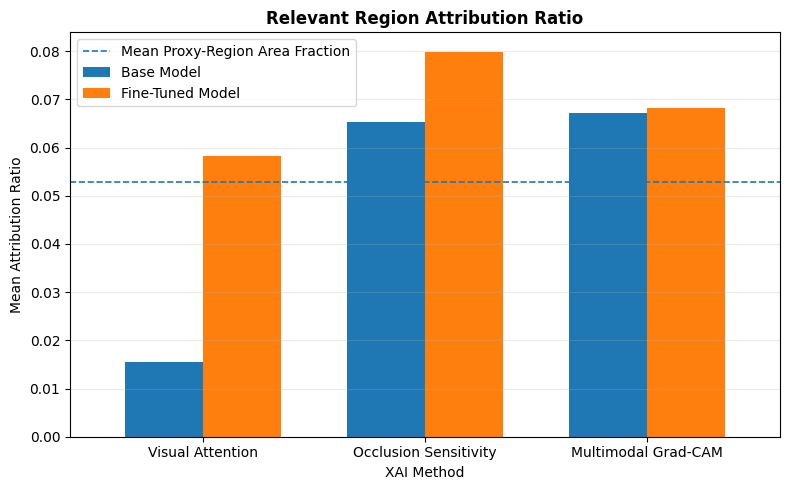

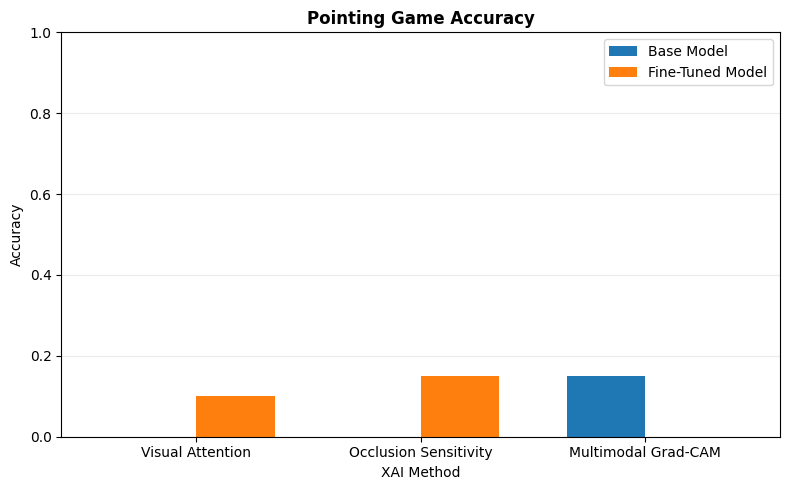

In [ ]:
plot_df = xai_summary.copy()

method_order = [
    "Visual Attention",
    "Occlusion Sensitivity",
    "Multimodal Grad-CAM",
]

# Relevant Region Attribution Ratio
rra_plot = (
    plot_df[
        plot_df["Metric"]
        == "Relevant Region Attribution Ratio"
    ]
    .set_index("XAI Method")
    .loc[method_order]
)


ax = rra_plot[
    [
        "Base Model",
        "Fine-Tuned Model",
    ]
].plot(
    kind="bar",
    figsize=(8, 5),
    width=0.7,
)

ax.axhline(
    np.mean(mask_areas),
    linestyle="--",
    linewidth=1.2,
    label="Mean Proxy-Region Area Fraction",
)

ax.set_title(
    "Relevant Region Attribution Ratio",
    fontweight="bold",
)

ax.set_xlabel("XAI Method")

ax.set_ylabel(
    "Mean Attribution Ratio"
)

ax.tick_params(
    axis="x",
    rotation=0,
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25,
)

plt.tight_layout()
plt.show()


# Pointing Game Accuracy

pointing_plot = (
    plot_df[
        plot_df["Metric"]
        == "Pointing Game Accuracy"
    ]
    .set_index("XAI Method")
    .loc[method_order]
)


ax = pointing_plot[
    [
        "Base Model",
        "Fine-Tuned Model",
    ]
].plot(
    kind="bar",
    figsize=(8, 5),
    width=0.7,
)

ax.set_title(
    "Pointing Game Accuracy",
    fontweight="bold",
)

ax.set_xlabel("XAI Method")

ax.set_ylabel(
    "Accuracy"
)

ax.set_ylim(
    0,
    1,
)

ax.tick_params(
    axis="x",
    rotation=0,
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25,
)

plt.tight_layout()
plt.show()

**Select Qualitative Cases**

In [ ]:
scene_a_pool = hazard_pairs[
    (hazard_pairs["comparison_case"] == "Fine-Tuned Improvement")
    & (hazard_pairs["ground_truth_anomaly"] == 1)
]
scene_b_pool = hazard_pairs[
    (hazard_pairs["comparison_case"] == "Fine-Tuned Regression")
    & (hazard_pairs["ground_truth_anomaly"] == 0)
]

assert len(scene_a_pool) > 0, "No Fine-Tuned Improvement positive case found."
assert len(scene_b_pool) > 0, "No Fine-Tuned Regression negative case found."

scene_a = scene_a_pool.sample(1, random_state=RANDOM_STATE).iloc[0]
scene_b = scene_b_pool.sample(1, random_state=RANDOM_STATE).iloc[0]

selected_cases = pd.DataFrame([
    {
        "Scene": "A — Fine-Tuned Improvement",
        "evaluation_id": scene_a["evaluation_id"],
        "ground_truth": scene_a["ground_truth_anomaly"],
        "base_prediction": scene_a["base_prediction"],
        "fine_prediction": scene_a["fine_prediction"],
    },
    {
        "Scene": "B — Fine-Tuned Regression",
        "evaluation_id": scene_b["evaluation_id"],
        "ground_truth": scene_b["ground_truth_anomaly"],
        "base_prediction": scene_b["base_prediction"],
        "fine_prediction": scene_b["fine_prediction"],
    },
])

display(selected_cases)


,Scene,evaluation_id,ground_truth,base_prediction,fine_prediction
0,A — Fine-Tuned Improvement,hazard_and_anomaly_detection::frankfurt_000000...,1,0,1
1,B — Fine-Tuned Regression,hazard_and_anomaly_detection::frankfurt_000001...,0,0,1


**Extract or Load Qualitative Maps**

In [ ]:
def compute_case_maps(row):
    image = Image.open(row["image_path"]).convert("RGB")
    targets = {
        "Base Model": response_ids(row["base_output"]),
        "Fine-Tuned Model": response_ids(row["fine_output"]),
    }
    adapters = {"Base Model": False, "Fine-Tuned Model": True}

    maps = {}
    for method_name, method_fn in METHODS.items():
        maps[method_name] = {
            model_name: method_fn(
                row,
                image,
                targets[model_name],
                adapters[model_name],
            )
            for model_name in ["Base Model", "Fine-Tuned Model"]
        }
    return image, maps


def load_positive_case_maps(row):
    path = map_path(row["evaluation_id"])
    if not path.exists():
        return compute_case_maps(row)

    image = Image.open(row["image_path"]).convert("RGB")
    data = np.load(path)
    maps = {}
    for method_name in METHODS:
        maps[method_name] = {}
        for model_name in ["Base Model", "Fine-Tuned Model"]:
            key = f"{safe_id(method_name)}__{safe_id(model_name)}"
            maps[method_name][model_name] = data[key]
    return image, maps


scene_a_image, scene_a_maps = load_positive_case_maps(scene_a)
scene_b_image, scene_b_maps = compute_case_maps(scene_b)

print("Qualitative maps ready.")


Qualitative maps ready.


**Qualitative XAI Visualizations**

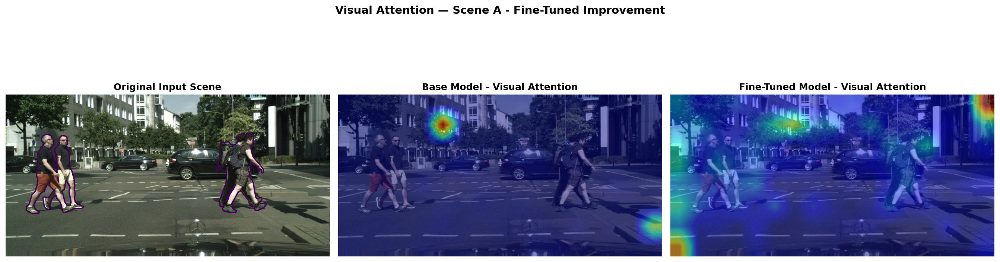

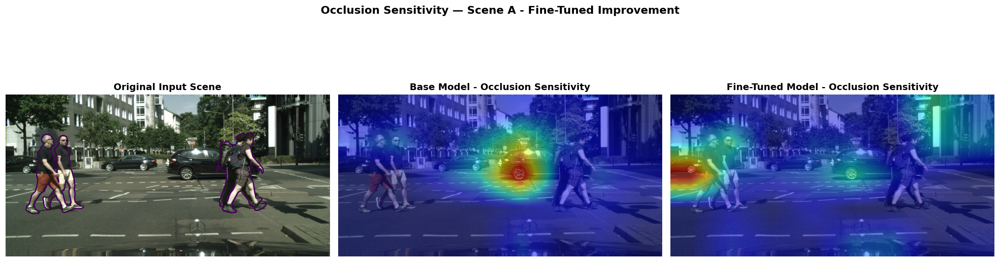

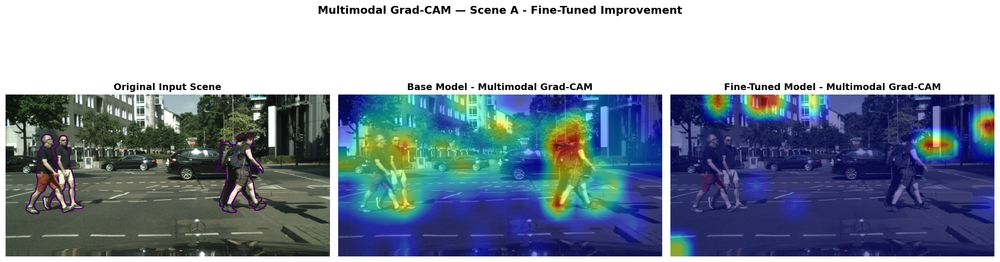

Evaluation ID: hazard_and_anomaly_detection::frankfurt_000000_014480
Ground Truth: 1
Base Prediction: 0
Fine-Tuned Prediction: 1

Base Model Output:
 Decision: No

Hazard type: None

Involved objects: None

Location: None

Severity: None

Visible evidence: The image shows pedestrians crossing the street at a marked crosswalk, and vehicles (including a black SUV and a sedan) are either stationary or moving in the background. There are no vulnerable

Fine-Tuned Model Output:
 Potential hazard: 3 pedestrian(s)/rider(s) near the roadway; 4 vehicle(s) that may affect traffic flow. Recommended action: slow down and yield to vulnerable road users; maintain a safe following distance.


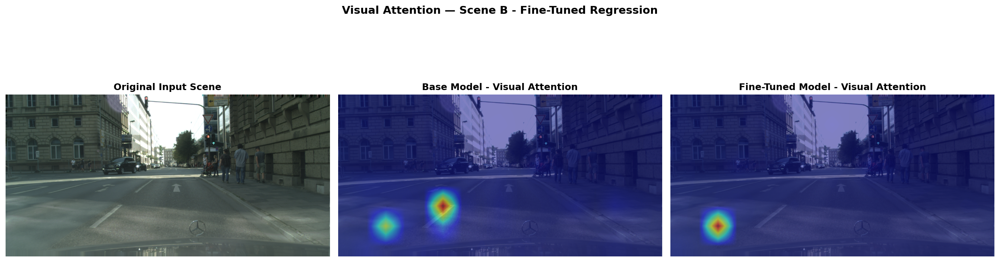

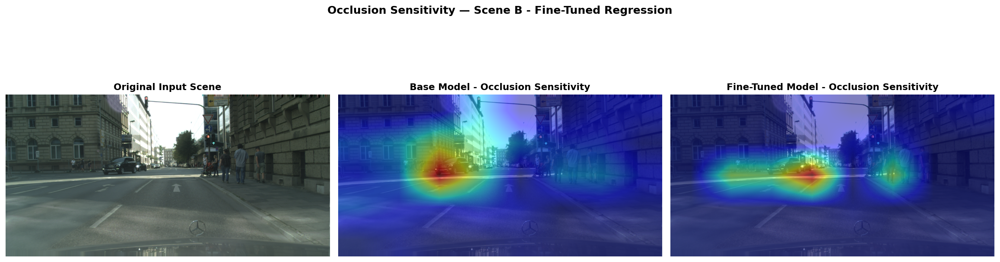

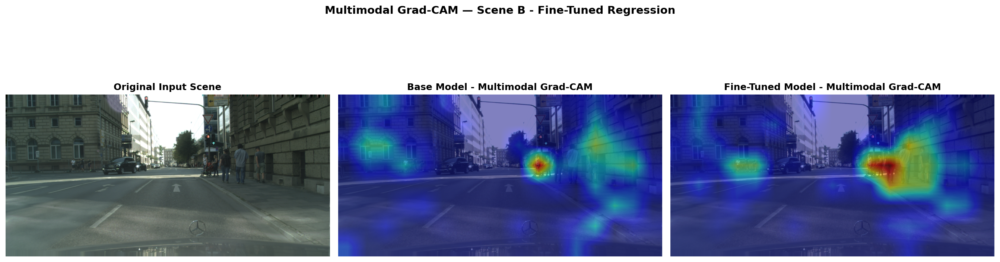

Evaluation ID: hazard_and_anomaly_detection::frankfurt_000001_051737
Ground Truth: 0
Base Prediction: 0
Fine-Tuned Prediction: 1

Base Model Output:
 Decision: No

Reasoning:
- The image shows a street scene with pedestrians on the sidewalk and a car parked on the left side of the road.
- There are no vulnerable road users (e.g., cyclists, pedestrians) in the directly drivable area (the road surface in front of the vehicle’s perspective).

Fine-Tuned Model Output:
 Potential hazards: 10 pedestrian(s)/rider(s) near the roadway; 5 vehicle(s) that may affect traffic flow. Recommended action: slow down and yield to vulnerable road users; maintain a safe following distance.


In [ ]:
def plot_case(row, image, maps, scene_title, show_mask=False):
    image_arr = np.asarray(image)
    mask = build_proxy_mask(row) if show_mask else None

    for method_name, method_maps in maps.items():
        fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150)

        axes[0].imshow(image_arr)
        if mask is not None:
            axes[0].contour(mask.astype(float), levels=[0.5], linewidths=1.5)
        axes[0].set_title("Original Input Scene", fontweight="bold")
        axes[0].axis("off")

        for ax, model_name in zip(axes[1:], ["Base Model", "Fine-Tuned Model"]):
            ax.imshow(image_arr)
            ax.imshow(
                normalize_map(method_maps[model_name]),
                cmap="jet",
                alpha=0.50,
                vmin=0,
                vmax=1,
            )
            ax.set_title(f"{model_name} - {method_name}", fontweight="bold")
            ax.axis("off")

        fig.suptitle(f"{method_name} — {scene_title}", fontsize=14, fontweight="bold")
        fig.tight_layout()

        filename = f"{safe_id(scene_title)}__{safe_id(method_name)}.png"
        fig.savefig(FIGURE_DIR / filename, dpi=200, bbox_inches="tight")
        plt.show()

    print("Evaluation ID:", row["evaluation_id"])
    print("Ground Truth:", int(row["ground_truth_anomaly"]))
    print("Base Prediction:", int(row["base_prediction"]))
    print("Fine-Tuned Prediction:", int(row["fine_prediction"]))
    print("\nBase Model Output:\n", row["base_output"])
    print("\nFine-Tuned Model Output:\n", row["fine_output"])


plot_case(
    scene_a,
    scene_a_image,
    scene_a_maps,
    "Scene A - Fine-Tuned Improvement",
    show_mask=True,
)

plot_case(
    scene_b,
    scene_b_image,
    scene_b_maps,
    "Scene B - Fine-Tuned Regression",
    show_mask=False,
)


**Save XAI Results**

In [ ]:
xai_metrics.to_csv(
    RESULTS_DIR / "xai_positive_spatial_metrics.csv",
    index=False,
)
xai_summary.to_csv(
    RESULTS_DIR / "xai_positive_spatial_summary.csv",
    index=False,
)
case_distribution.to_csv(
    RESULTS_DIR / "xai_case_distribution.csv",
    index=False,
)
selected_cases.to_csv(
    RESULTS_DIR / "xai_selected_qualitative_cases.csv",
    index=False,
)

print("Saved XAI results to:")
print(RESULTS_DIR)


Saved XAI results to:
C:\Users\becker\Documents\Thesis\dataset\CityScapes\xai_results_ds2
